In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
import scipy as sp

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "RubberLeafDiseases",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 603 files belonging to 7 classes.


In [4]:
class_names = dataset.class_names
class_names

['Birdseye_leaf_disease',
 'Colletrotrichum',
 'Corynespora_leaf_fall_disease',
 'New_leaf_disease',
 'Oidium',
 'Pestalotiopsis',
 'random']

In [5]:
len(dataset)

19

In [6]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[1 2 6 4 3 4 1 2 0 1 3 6 6 5 4 5 5 6 6 0 4 4 6 0 2 1 3 3 6 6 3 4]


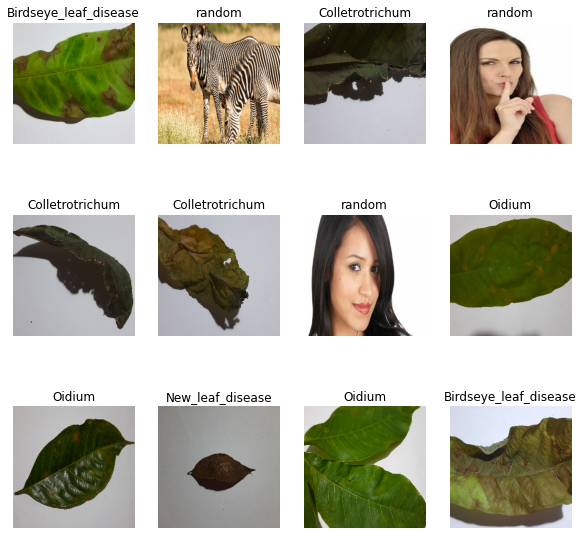

In [7]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [8]:
len(dataset)

19

In [9]:
train_size = 0.8
len(dataset)*train_size

15.200000000000001

In [10]:
train_ds = dataset.take(15)
len(train_ds)

15

In [11]:
test_ds = dataset.skip(15)
len(test_ds)

4

In [12]:
val_size=0.1
len(dataset)*val_size

1.9000000000000001

In [13]:
val_ds = test_ds.take(1)
len(val_ds)

1

In [14]:
test_ds = test_ds.skip(1)
len(test_ds)

3

In [15]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [17]:
len(train_ds)

15

In [18]:
len(val_ds)

1

In [19]:
len(test_ds)

3

In [20]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [22]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [23]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 7

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [24]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (32, 127, 127, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (32, 62, 62, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (32, 60, 60, 64)         

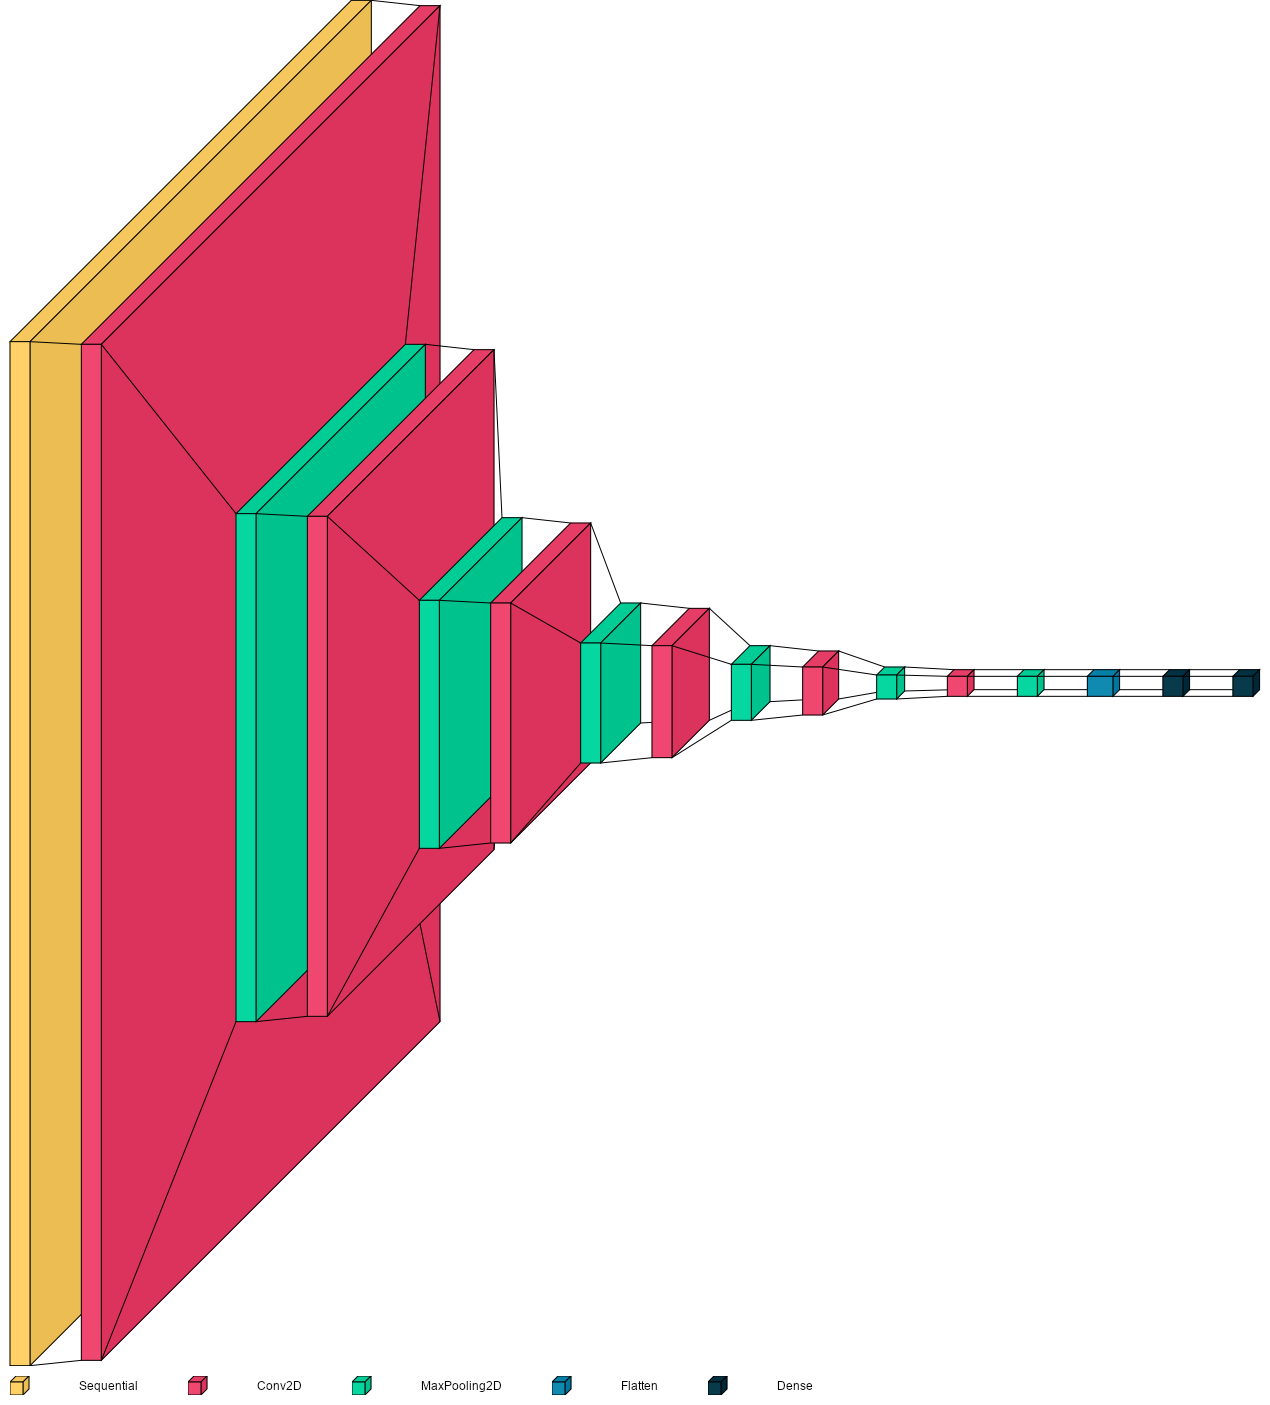

In [25]:
import visualkeras
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12, encoding="unic")
visualkeras.layered_view(model, legend=True, spacing=50,font=font)

In [26]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [27]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [28]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=100,
)

Epoch 1/100
15/15 [==============================] - 91s 4s/step - loss: 1.8772 - accuracy: 0.2083 - val_loss: 1.7094 - val_accuracy: 0.2500
Epoch 2/100
15/15 [==============================] - 40s 3s/step - loss: 1.6578 - accuracy: 0.3375 - val_loss: 1.4006 - val_accuracy: 0.4688
Epoch 3/100
15/15 [==============================] - 41s 3s/step - loss: 1.4721 - accuracy: 0.4333 - val_loss: 1.5398 - val_accuracy: 0.4062
Epoch 4/100
15/15 [==============================] - 40s 3s/step - loss: 1.4324 - accuracy: 0.4542 - val_loss: 1.3722 - val_accuracy: 0.4062
Epoch 5/100
15/15 [==============================] - 40s 3s/step - loss: 1.3351 - accuracy: 0.4708 - val_loss: 1.1552 - val_accuracy: 0.5000
Epoch 6/100
15/15 [==============================] - 40s 3s/step - loss: 1.2880 - accuracy: 0.4917 - val_loss: 1.1127 - val_accuracy: 0.5625
Epoch 7/100
15/15 [==============================] - 41s 3s/step - loss: 1.1895 - accuracy: 0.5562 - val_loss: 1.0299 - val_accuracy: 0.5625
Epoch 8/100
1

Epoch 59/100
15/15 [==============================] - 41s 3s/step - loss: 0.1441 - accuracy: 0.9458 - val_loss: 0.0997 - val_accuracy: 0.9688
Epoch 60/100
15/15 [==============================] - 41s 3s/step - loss: 0.1778 - accuracy: 0.9521 - val_loss: 0.3547 - val_accuracy: 0.9375
Epoch 61/100
15/15 [==============================] - 40s 3s/step - loss: 0.1623 - accuracy: 0.9375 - val_loss: 0.1458 - val_accuracy: 0.9375
Epoch 62/100
15/15 [==============================] - 40s 3s/step - loss: 0.1518 - accuracy: 0.9542 - val_loss: 0.1586 - val_accuracy: 0.9062
Epoch 63/100
15/15 [==============================] - 40s 3s/step - loss: 0.1399 - accuracy: 0.9521 - val_loss: 0.4699 - val_accuracy: 0.8750
Epoch 64/100
15/15 [==============================] - 40s 3s/step - loss: 0.1126 - accuracy: 0.9625 - val_loss: 0.1453 - val_accuracy: 0.9375
Epoch 65/100
15/15 [==============================] - 41s 3s/step - loss: 0.1121 - accuracy: 0.9563 - val_loss: 0.1434 - val_accuracy: 0.9375
Epoch 

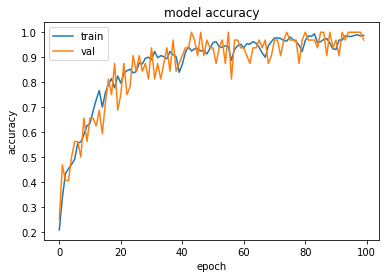

In [29]:
#training accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

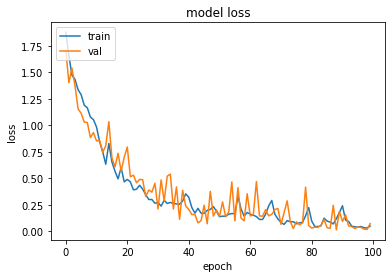

In [30]:
#loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [31]:
scores = model.evaluate(test_ds)

3/3 [==============================] - 23s 644ms/step - loss: 0.1265 - accuracy: 0.9688


In [32]:
scores

[0.1264798939228058, 0.96875]

In [33]:
history

In [34]:
history.params

{'verbose': 1, 'epochs': 100, 'steps': 15}

In [35]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [36]:
type(history.history['loss'])

list

In [37]:
len(history.history['loss'])

100

In [38]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.8772051334381104,
 1.6577907800674438,
 1.472074031829834,
 1.4323582649230957,
 1.3351370096206665]

In [39]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

NameError: name 'EPOCHS' is not defined

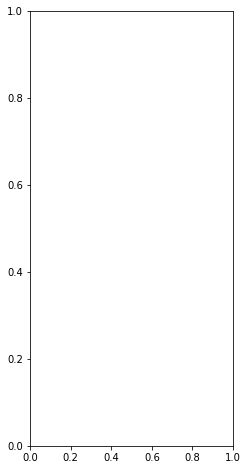

In [40]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: New_leaf_disease
predicted label: New_leaf_disease


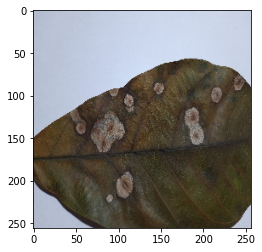

In [41]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [42]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

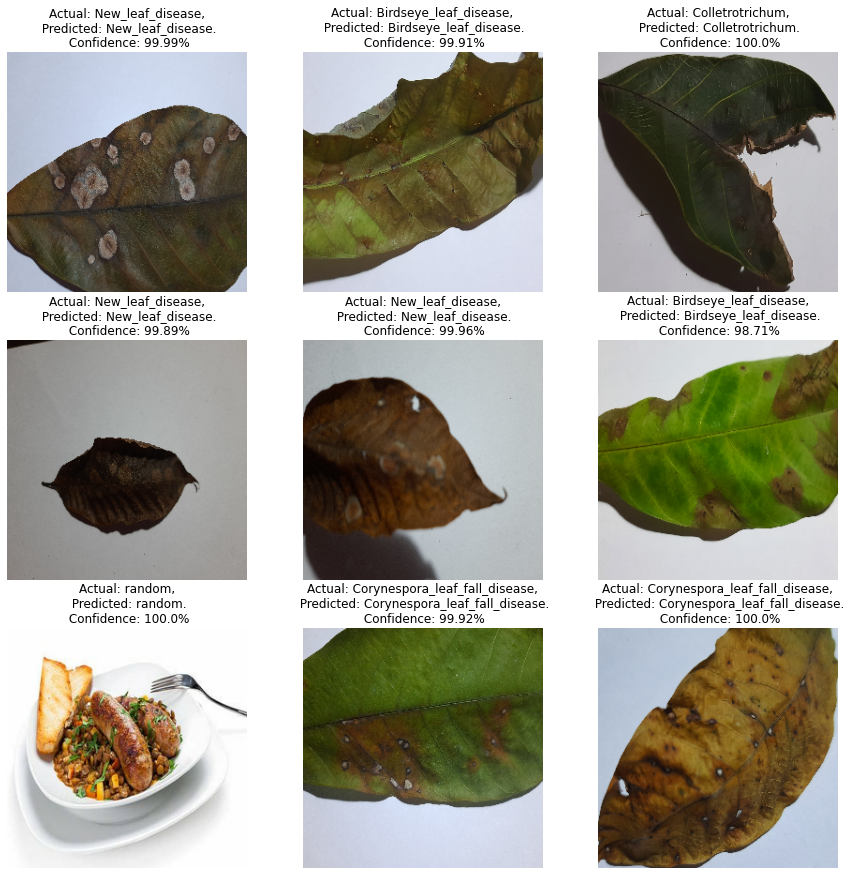

In [43]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [45]:
import os
model_version=max([int(i) for i in os.listdir("models") + [0]])+1
model.save(f"models/{model_version}")

INFO:tensorflow:Assets written to: models/1\assets


In [46]:
model.save("RubberLeafDiseasesModel1.h5")

Oidium


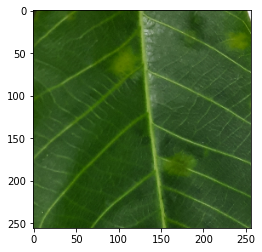

In [48]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
img = image.load_img("C:/Users/Dell/Documents/SLIIT/4th Year/2nd Semester/Research/Model Training/RubberLeafDiseases/Oidium/20220306_213546.jpg",target_size=(256,256))
img = np.asarray(img)
plt.imshow(img)
img = np.expand_dims(img, axis=0)
from tensorflow.keras.models import load_model
saved_model = load_model("RubberLeafDiseasesModel1.h5")
output = saved_model.predict(img)

# print(output)
if output[0][0] > output[0][1]:
    print("Colletrotrichum")
else:
    print("Oidium")